In [681]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [682]:
from ipywidgets import interact
from IPython.display import display


import importlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn import linear_model

from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from data import utils

from models import NDVIClimatologyGAM

from features import (
    FeaturePipeline, 
    PhenologyFeatures, 
    RollingFeatures, 
    SoilFeatures, 
    TemporalFeatures
)


In [683]:
non_spectral_df = pd.read_csv("../data/raw/non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])
spectral_df = pd.read_csv("../data/raw/spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])
grouped_spectral_df = pd.read_csv("../data/raw/grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])
master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)
master_df["doy"] = master_df["Timestamp"].dt.dayofyear
master_df.head()

,Timestamp,NDVI_mean,NDVI_std,NDWI_mean,NDWI_std,NDRE_mean,NDRE_std,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,doy
0,2018-01-07,0.454175,0.017789,0.154850,0.001513,0.301027,0.005391,0.277943,0.320916,0.297231,0.270322,298.093380,296.435354,293.480139,291.139993,296.411982,288.101550,305.198672,3.187154e+07,0.000000,7
1,2018-03-03,0.629801,0.031419,0.310717,0.025493,0.438958,0.033150,0.275499,0.294964,0.281848,0.269882,296.319232,295.264591,293.797097,292.708587,293.174303,284.739623,300.874879,2.653625e+07,5.928807,62
2,2018-06-01,0.330054,0.013942,0.073200,0.005519,0.220654,0.008582,0.387392,0.309780,0.338261,0.271122,283.614288,284.567219,286.777798,290.473939,281.743066,275.021431,288.422674,1.504906e+07,0.000000,152
3,2018-06-06,0.289118,0.015937,-0.017437,0.002453,0.180388,0.010207,0.336953,0.310565,0.336209,0.271163,281.924616,282.769941,285.820755,290.178382,280.752142,274.098569,288.798194,1.452415e+07,0.000000,157
4,2018-06-11,0.264834,0.027659,-0.018403,0.011886,0.172670,0.016877,0.307676,0.305746,0.333914,0.271199,282.930785,283.265651,285.249282,289.847651,281.838309,276.769477,289.060574,1.396338e+07,0.000000,162


100% (25 of 25) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


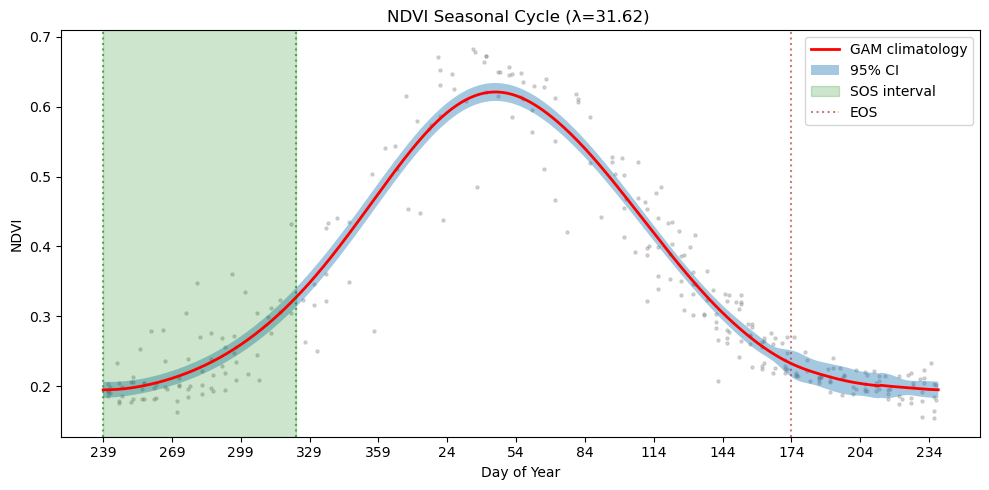

In [684]:
gam = NDVIClimatologyGAM(n_splines=30)

X = master_df["doy"].values.reshape(-1, 1)
y = master_df["NDVI_mean"].values

gam.gridsearch(doys=X, ndvi=y)
gam.plot_climatology(season_lines=True)
sos = gam.start_of_season(position="start")
eos = gam.end_of_season()

In [685]:
eos

np.int64(174)

In [686]:
sos=300
eos = 173
phen = PhenologyFeatures(start_of_season=sos, end_of_season=eos)


In [687]:
test_df = phen.transform(non_spectral_df)
test_df[test_df["in_season"] == 1]

1
239


,Timestamp,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,Ag_year,in_season,GDD,cumulative_GDD,Growth_Stage
0,2018-01-01,0.371225,0.394800,0.302474,0.270380,294.466628,294.026363,293.144239,290.955942,293.314439,284.922923,301.389491,3.288490e+07,0.000000,2017,1,10.006207,10.006207,SoS
1,2018-01-02,0.347555,0.379907,0.302010,0.270373,293.848773,293.884632,293.162249,290.987094,289.883795,285.298415,295.811490,3.127135e+07,0.000000,2017,1,7.404952,17.411159,SoS
2,2018-01-03,0.330737,0.367946,0.301465,0.270366,293.911082,293.727159,293.150462,291.017846,290.475579,283.975136,296.656369,2.872766e+07,0.000000,2017,1,7.165753,24.576912,SoS
3,2018-01-04,0.315402,0.356416,0.300741,0.270358,294.503247,293.925443,293.141661,291.047929,291.254956,283.692780,298.823837,3.154392e+07,2.618651,2017,1,8.108309,32.685221,SoS
4,2018-01-05,0.302094,0.344448,0.299777,0.270349,295.542367,294.539959,293.180125,291.077664,293.653434,284.633106,302.508414,3.183471e+07,1.835338,2017,1,10.420760,43.105980,SoS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2916,2025-12-26,0.453518,0.462387,0.451275,0.368383,294.253327,293.347155,291.678065,289.233364,292.772075,286.809729,298.725012,2.853510e+07,0.000000,2025,1,9.617370,429.226627,V8-V9
2917,2025-12-27,0.445713,0.452212,0.449648,0.368676,294.211534,293.653735,291.806207,289.275173,292.766398,288.546868,298.950326,2.671594e+07,0.000000,2025,1,10.598597,439.825224,V8-V9
2918,2025-12-28,0.451453,0.453876,0.447944,0.368945,293.850357,293.533509,291.918364,289.318510,291.567403,288.298707,297.201681,2.507932e+07,0.769881,2025,1,9.600194,449.425418,V8-V9
2919,2025-12-29,0.446050,0.460449,0.446939,0.369193,294.235965,293.554248,291.999941,289.362576,292.323319,288.560556,297.323131,2.635016e+07,2.580112,2025,1,9.791844,459.217262,V8-V9


In [688]:
test_df["Timestamp"] = pd.to_datetime(test_df["Timestamp"])
plot_df = grouped_spectral_df.merge(test_df, how='right', on="Timestamp")


In [689]:
plot_df["NDVI_mean"].isna().sum()


np.int64(2616)

In [691]:
phen.plot_growth(plot_df, all_years=True, shifted=True, growth_stages=False)

interactive(children=(Dropdown(description='plot_year', options=(np.int32(2017), np.int32(2018), np.int32(2019…